In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='disease_progression')

# Exploratory data analysis
print("Dataset shape:", X.shape)
print("First 5 rows:\n", X.head())
print("\nTarget summary:\n", y.describe())
print("\nMissing values:\n", X.isnull().sum())

Dataset shape: (442, 10)
First 5 rows:
         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Target summary:
 count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: disease_progression, dtype: float64

Missing values:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4  


--- Simple Linear Regression ---
MAE: 52.259976445345536
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R2 Score: 0.23335039815872138


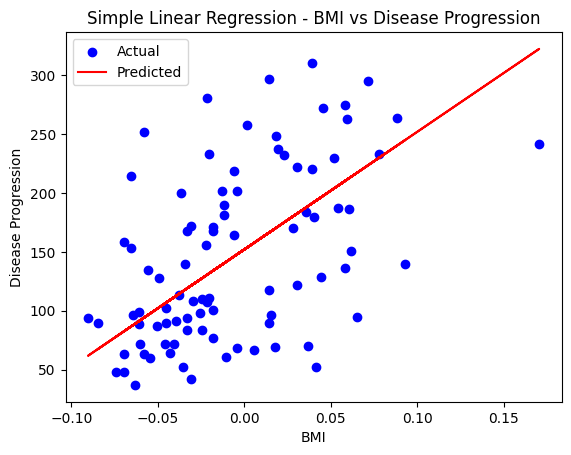

In [3]:
X_bmi = X[['bmi']]
X_train, X_test, y_train, y_test = train_test_split(X_bmi, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print("\n--- Simple Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title("Simple Linear Regression - BMI vs Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.show()

In [4]:
# Step 2: Multiple Linear Regression
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
multi_reg = LinearRegression()
multi_reg.fit(X_train_full, y_train)
y_pred_multi = multi_reg.predict(X_test_full)

print("\n--- Multiple Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print("R2 Score:", r2_score(y_test, y_pred_multi))


--- Multiple Linear Regression ---
MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R2 Score: 0.4526027629719195


In [5]:
# Step 3: Polynomial Regression
poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly.fit(X_train_full, y_train)
y_pred_poly = poly.predict(X_test_full)

print("\n--- Polynomial Regression (Degree=2) ---")
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("R2 Score:", r2_score(y_test, y_pred_poly))


--- Polynomial Regression (Degree=2) ---
MAE: 43.581693254652215
MSE: 3096.028307344255
RMSE: 55.641965344012206
R2 Score: 0.4156399336408033


In [6]:
# Step 4: Ridge and Lasso Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_full, y_train)
y_pred_ridge = ridge.predict(X_test_full)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_full, y_train)
y_pred_lasso = lasso.predict(X_test_full)

print("\n--- Ridge Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

print("\n--- Lasso Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))



--- Ridge Regression ---
MAE: 46.13885766697452
MSE: 3077.41593882723
RMSE: 55.47446204180109
R2 Score: 0.41915292635986545

--- Lasso Regression ---
MAE: 42.85442771664998
MSE: 2798.193485169719
RMSE: 52.897953506442185
R2 Score: 0.4718547867276227
